In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

ruta = r'C:\Users\jthow\iCloudDrive\Documents\3_Maestria_Estadistica_UNINORTE\3_Tercer_Semestre\Machine_Learning\tornados.csv.zip'  
df = pd.read_csv(ruta) 
df['loss'] = df['loss'].replace(0, pd.NA)
df['loss'] = df['loss'].interpolate(method='linear')
df['mag'] = df['mag'].fillna(df['mag'].mean())
df.isnull().sum()

om              0
yr              0
mo              0
dy              0
date            0
time            0
tz              0
datetime_utc    0
st              0
stf             0
mag             0
inj             0
fat             0
loss            0
slat            0
slon            0
elat            0
elon            0
len             0
wid             0
ns              0
sn              0
f1              0
f2              0
f3              0
f4              0
fc              0
dtype: int64

In [ ]:
pip install xgboost

In [2]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import numpy as np

# Crear la columna 'mortality' en el DataFrame original
df['mortality'] = df['fat'].apply(lambda x: 0 if x == 0 else 1)

# Renombrar el DataFrame a 'mortality_target'
mortality_target = df
import numpy as np

# Crear la columna 'mortality' con 0 si 'fat' es 0, y 1 si 'fat' es mayor que 0
df['mortality'] = np.where(df['fat'] == 0, 0, 1)
# Asignar el DataFrame modificado a 'tornados.target'
tornados_target = df

X = tornados_target[['om', 'yr', 'mo', 'dy', 'stf', 'mag', 'inj', 'loss', 'slat', 'slon', 'elat', 'elon', 'len', 'wid', 'ns', 'sn', 'f1', 'f2', 'f3', 'f4']]
y = df['mortality']

# Asumiendo que ya tienes X y y preparados como en tu código anterior
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Crear el modelo XGBoost
xgboost_model = xgb.XGBClassifier(random_state=0)

# Ajustar el modelo con los datos de entrenamiento
xgboost_model.fit(X_train, y_train)

# Evaluar la precisión en el conjunto de entrenamiento y prueba
print("Accuracy on training set: {:.3f}".format(xgboost_model.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(xgboost_model.score(X_test, y_test)))

Accuracy on training set: 0.996
Accuracy on test set: 0.982


In [3]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Dividir los datos en conjunto de entrenamiento y prueba (asegurando que X y y ya están definidos)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Parámetros a comparar
params = [
    {'learning_rate': 0.1, 'n_estimators': 100, 'random_state': 0},
    {'learning_rate': 0.05, 'n_estimators': 100, 'random_state': 0},
    {'max_depth': 5, 'n_estimators': 100, 'random_state': 0},
    {'subsample': 0.8, 'n_estimators': 100, 'random_state': 0},
    {'colsample_bytree': 0.8, 'n_estimators': 100, 'random_state': 0}
]

# Lista para almacenar resultados
results = []

# Probar cada conjunto de parámetros
for param in params:
    xgboost_model = xgb.XGBClassifier(**param)
    xgboost_model.fit(X_train, y_train)
    y_pred = xgboost_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results.append((param, accuracy))

# Mostrar los resultados
for param, accuracy in results:
    print(f"Parameters: {param} -> Accuracy: {accuracy:.4f}")

Parameters: {'learning_rate': 0.1, 'n_estimators': 100, 'random_state': 0} -> Accuracy: 0.9819
Parameters: {'learning_rate': 0.05, 'n_estimators': 100, 'random_state': 0} -> Accuracy: 0.9824
Parameters: {'max_depth': 5, 'n_estimators': 100, 'random_state': 0} -> Accuracy: 0.9818
Parameters: {'subsample': 0.8, 'n_estimators': 100, 'random_state': 0} -> Accuracy: 0.9806
Parameters: {'colsample_bytree': 0.8, 'n_estimators': 100, 'random_state': 0} -> Accuracy: 0.9813


In [ ]:
pip install --upgrade xgboost

In [ ]:
pip install --upgrade scikit-learn

In [5]:
# Definir el modelo XGBoost sin GridSearchCV
xgboost_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=0)

# Ajustar el modelo con los datos de entrenamiento
xgboost_model.fit(X_train, y_train)

# Evaluar la precisión en el conjunto de entrenamiento y prueba
print("Accuracy on training set: {:.3f}".format(xgboost_model.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(xgboost_model.score(X_test, y_test)))

Accuracy on training set: 0.987
Accuracy on test set: 0.982


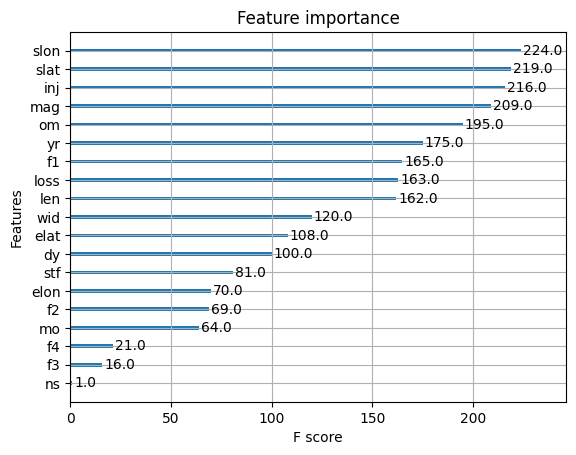

In [6]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Visualizar la importancia de las características
plot_importance(xgboost_model)
plt.show()

In [7]:
# Predicciones en el conjunto de test
y_pred = xgboost_model.predict(X_test)

# Calcular la precisión (accuracy)
from sklearn.metrics import accuracy_score
print("Accuracy on test set: {:.3f}".format(accuracy_score(y_test, y_pred)))

Accuracy on test set: 0.982


In [8]:
params = {
    'objective': 'binary:logistic',
    'max_depth': 5,
    'learning_rate': 0.05,
    'n_estimators': 100
}

# Realizar validación cruzada
cv_results = xgb.cv(params=params, dtrain=xgb.DMatrix(X_train, label=y_train),
                    num_boost_round=100, early_stopping_rounds=10, nfold=3, verbose_eval=True)

# Ver resultados de la validación cruzada
print(cv_results)

[0]	train-logloss:0.17340+0.00044	test-logloss:0.17365+0.00063
[1]	train-logloss:0.16568+0.00043	test-logloss:0.16615+0.00060
[2]	train-logloss:0.15862+0.00042	test-logloss:0.15935+0.00060
[3]	train-logloss:0.15211+0.00041	test-logloss:0.15306+0.00060
[4]	train-logloss:0.14606+0.00040	test-logloss:0.14727+0.00063
[5]	train-logloss:0.14043+0.00038	test-logloss:0.14182+0.00063
[6]	train-logloss:0.13514+0.00038	test-logloss:0.13675+0.00065
[7]	train-logloss:0.13016+0.00037	test-logloss:0.13197+0.00064
[8]	train-logloss:0.12550+0.00036	test-logloss:0.12749+0.00065
[9]	train-logloss:0.12114+0.00036	test-logloss:0.12329+0.00065
[10]	train-logloss:0.11704+0.00034	test-logloss:0.11934+0.00067
[11]	train-logloss:0.11317+0.00036	test-logloss:0.11564+0.00068
[12]	train-logloss:0.10951+0.00034	test-logloss:0.11216+0.00067
[13]	train-logloss:0.10606+0.00035	test-logloss:0.10889+0.00066
[14]	train-logloss:0.10283+0.00036	test-logloss:0.10580+0.00065
[15]	train-logloss:0.09977+0.00037	test-logloss:0.

In [9]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score, precision_score, recall_score, accuracy_score, f1_score, roc_auc_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
from joblib import dump

# Suponiendo que X_train, X_test, y_train, y_test ya están definidas

# Definir el pipeline para el modelo de XGBRegressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(random_state=42, objective='reg:squarederror'))
])

# Definir el grid de hiperparámetros para XGBRegressor
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2]
}

# Realizar GridSearchCV para el modelo
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# Guardar el modelo
dump(grid_search, 'XGBRegressor.joblib')

# Calcular las métricas para el modelo
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

# Métricas de regresión
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
jb_p_value = jarque_bera(residuals)[1]

# Convertir el problema de regresión a clasificación
# Por ejemplo, usamos la mediana de y_test como umbral
threshold = np.median(y_test)
y_test_class = (y_test > threshold).astype(int)
y_pred_class = (y_pred > threshold).astype(int)

# Métricas de clasificación
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
accuracy = accuracy_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)
auc = roc_auc_score(y_test_class, y_pred_class)

# Crear un DataFrame para las métricas
metrics = {
    "Modelo": ["XGBRegressor"],
    "MAPE": [f"{mape:.2f}"],
    "RMSE": [f"{rmse:.2f}"],
    "R Cuadrado": [f"{r2:.2f}"],
    "Jarque-Bera p-value": [f"{jb_p_value:.2f}"],
    "Precisión": [f"{precision:.2f}"],
    "Recall": [f"{recall:.2f}"],
    "Accuracy": [f"{accuracy:.2f}"],
    "F1-score": [f"{f1:.2f}"],
    "AUC": [f"{auc:.2f}"]
}

metrics_df = pd.DataFrame(metrics)

# Mostrar la tabla combinada
print("Métricas para el modelo de XGBRegressor:")
print(metrics_df)

Métricas para el modelo de XGBRegressor:
         Modelo               MAPE  RMSE R Cuadrado Jarque-Bera p-value  \
0  XGBRegressor  64985254330368.00  0.12       0.38                0.00   

  Precisión Recall Accuracy F1-score   AUC  
0      0.03   0.99     0.21     0.05  0.59  


In [11]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import acorr_ljungbox

# Suponiendo que X_train, X_test, y_train, y_test ya están definidas

# Definir el pipeline para el modelo de XGBRegressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(random_state=42, objective='reg:squarederror'))
])

# Ajustar el modelo
pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred = pipeline.predict(X_test)

# Calcular los residuos
residuals = y_test - y_pred

# Realizar el Ljung-Box test para comprobar autocorrelación en los residuos
# Realizar el Ljung-Box test para comprobar autocorrelación en los residuos
ljung_box_test = acorr_ljungbox(residuals, lags=[10], return_df=True)

# Imprimir el resultado del Ljung-Box test
print(f"Ljung-Box Test statistic: {ljung_box_test['lb_stat'].iloc[-1]:.4f}")
print(f"Ljung-Box Test p-value: {ljung_box_test['lb_pvalue'].iloc[-1]:.4f}")


Ljung-Box Test statistic: 17.9329
Ljung-Box Test p-value: 0.0561
